## Import Libraries

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [112]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root))


from src.arima_model import train_arima, forecast_arima
from src.lstm_model import build_lstm

In [104]:
from src.arima_model import train_arima, forecast_arima

In [106]:
model_fit = train_arima(
    train,
    order=(1,1,1)
)

model_fit.summary()

c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 2516
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -8183.007
Date:                Tue, 07 Jul 2026   AIC                          16372.015
Time:                        23:05:34   BIC                          16389.505
Sample:                             0   HQIC                         16378.363
                               - 2516                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0040      1.723     -0.002      0.998      -3.380       3.372
ma.L1         -0.0021      1.721     -0.001      0.999      -3.375       3.371
sigma2        39.2284      0.444     88.330      0.000      38.358      40.099
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             11716.32
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):             536.46   Skew:                             0.12
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.57
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [107]:
forecast = forecast_arima(
    model_fit,
    steps=len(test)
)

c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [110]:
model = build_lstm()

c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [111]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

## Load Tesla Data

In [5]:
# Load the combined dataset
df = pd.read_csv("../data/processed/combined_data.csv")

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Filter only Tesla data
tsla = df[df["Ticker"] == "TSLA"].copy()

# Sort by date
tsla = tsla.sort_values("Date")

# Set Date as the index
tsla.set_index("Date", inplace=True)

# Display the first few rows
tsla.head()

,Open,High,Low,Close,Volume,Ticker
Date,,,,,,
2015-01-02,14.858000,14.883333,14.217333,14.620667,71466000,TSLA
2015-01-05,14.303333,14.433333,13.810667,14.006000,80527500,TSLA
2015-01-06,14.004000,14.280000,13.614000,14.085333,93928500,TSLA
2015-01-07,14.223333,14.318667,13.985333,14.063333,44526000,TSLA
2015-01-08,14.187333,14.253333,14.000667,14.041333,51637500,TSLA


Load and Prepare the Tesla Dataset

Load the combined dataset, filter the Tesla (TSLA) records, convert the Date column to datetime format, sort the data chronologically, and set the Date column as the index to prepare it for time series analysis.

In [6]:
tsla.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    2888 non-null   float64
 1   High    2888 non-null   float64
 2   Low     2888 non-null   float64
 3   Close   2888 non-null   float64
 4   Volume  2888 non-null   int64  
 5   Ticker  2888 non-null   str    
dtypes: float64(4), int64(1), str(1)
memory usage: 157.9 KB


## Use Only the Closing Price

In [9]:
price = tsla["Close"]

price.head()

Date
2015-01-02    14.620667
2015-01-05    14.006000
2015-01-06    14.085333
2015-01-07    14.063333
2015-01-08    14.041333
Name: Close, dtype: float64

 Select the Target Variable

The dataset contains several features, including Open, High, Low, Close, Volume, and Ticker. Since the objective is to forecast Tesla's stock price using a univariate time series model (ARIMA), only the **Close** price is selected.

The `Close` price represents the final trading price of the stock at the end of each trading day and serves as the target variable for forecasting.

## Split the Data (Very Important)

In [10]:
train = price[:'2024-12-31']
test = price['2025-01-01':]

In [11]:
print(len(train))
print(len(test))

2516
372


Split the Data into Training and Testing Sets

To evaluate the forecasting model fairly, the time series is split chronologically.

- **Training set (2015–2024):** Used to train the ARIMA model.
- **Testing set (2025–2026):** Used to evaluate the model's forecasting performance on unseen data.

Unlike traditional machine learning tasks, time series data must preserve the order of observations, so the split is based on dates rather than random sampling.

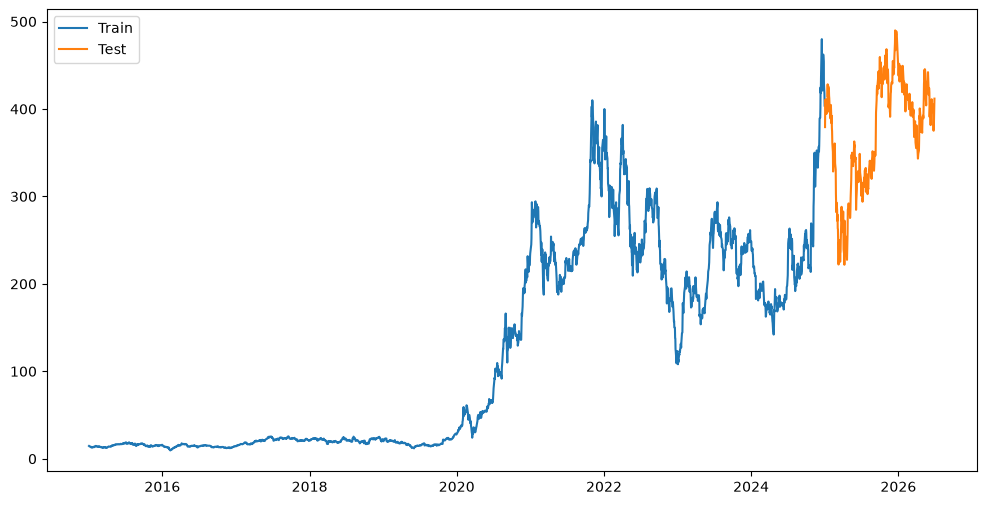

In [12]:
plt.figure(figsize=(12,6))

plt.plot(train, label="Train")
plt.plot(test, label="Test")

plt.legend()
plt.show()

Visualize the Train/Test Split

The training and testing datasets are plotted to verify that the chronological split has been applied correctly. The training data covers the historical period used for model fitting, while the testing data represents future observations used to evaluate forecasting accuracy.

## ACF and PACF

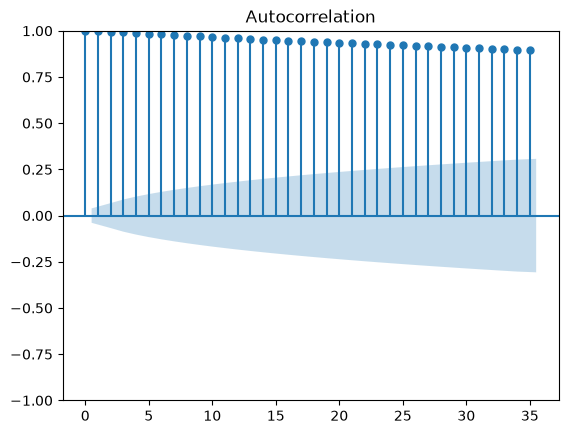

In [13]:
plot_acf(train)
plt.show()

 Autocorrelation Function (ACF)

The Autocorrelation Function (ACF) measures the correlation between the current observation and its previous values (lags). It helps identify how strongly historical observations influence the current value.

The ACF plot is commonly used to estimate the Moving Average (MA) component (`q`) of an ARIMA model by showing the correlation at different lag values.

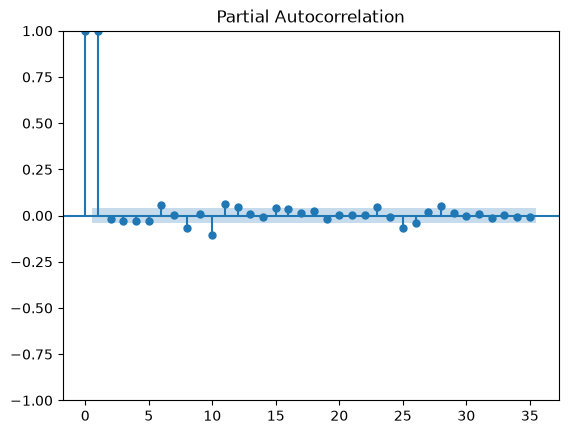

In [19]:
plot_pacf(train)
plt.show()

 Partial Autocorrelation Function (PACF)

The Partial Autocorrelation Function (PACF) measures the direct relationship between the current observation and its past values (lags), removing the effect of intermediate lags.

The PACF plot is used to estimate the Autoregressive (AR) component (`p`) of an ARIMA model by identifying significant lag relationships.

## Build the First ARIMA Model

In [15]:
model = ARIMA(train, order=(1,1,1))

c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 Build ARIMA Model

An ARIMA(1,1,1) model is created as the first baseline forecasting model.

- **p = 1**: Uses one previous observation (AR component).
- **d = 1**: Applies differencing once to make the series stationary.
- **q = 1**: Uses one previous forecast error (MA component).

In [16]:
model_fit = model.fit()

c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


 Fit the ARIMA Model

The model is fitted using the training data to learn the AR and MA parameters and estimate the best model coefficients.

In [17]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2516
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -8183.007
Date:                Tue, 07 Jul 2026   AIC                          16372.015
Time:                        10:07:10   BIC                          16389.505
Sample:                             0   HQIC                         16378.363
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0040      1.723     -0.002      0.998      -3.380       3.372
ma.L1         -0.0021      1.721     -0.001      0.999      -3.375       3.371
sigma2        39.2284      0.444     88.330      0.0

ARIMA Model Summary

The model summary provides information about model parameters, statistical significance, and evaluation metrics such as AIC and BIC to assess model performance.

## Generate ARIMA Forecasts

In [20]:
forecast = model_fit.forecast(steps=len(test))

c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [26]:
forecast = pd.Series(
    forecast.values,
    index=test.index
)

forecast.head()

Date
2025-01-02    403.923403
2025-01-03    403.923065
2025-01-06    403.923067
2025-01-07    403.923067
2025-01-08    403.923067
dtype: float64

## Plot ARIMA Forecast

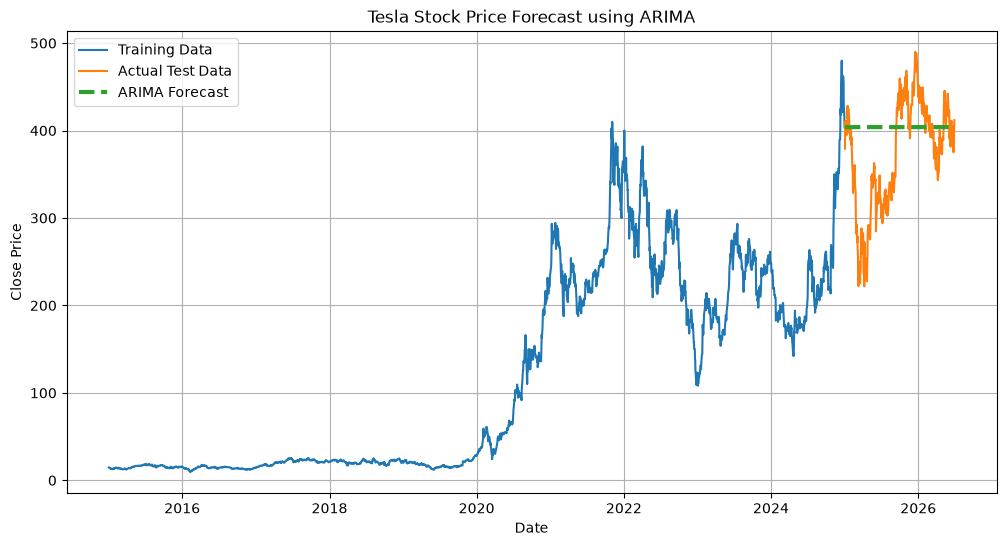

In [27]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Training Data")

plt.plot(test.index, test, label="Actual Test Data")

plt.plot(
    forecast.index,
    forecast,
    label="ARIMA Forecast",
    linestyle="--",
    linewidth=3
)

plt.title("Tesla Stock Price Forecast using ARIMA")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

"The blue line represents the training data used to fit the ARIMA model, while the orange line shows the actual stock prices in the test period. The green dashed line is the ARIMA forecast. We observe that the forecast is nearly flat, meaning the model predicts almost the same closing price for all future days. This occurs because the fitted ARIMA(1,1,1) model did not identify strong autoregressive or moving average relationships in the data, making it unable to capture Tesla's highly volatile price movements. This motivates comparing it with more advanced models such as Auto-ARIMA and LSTM.

## Evaluate ARIMA Model

In [32]:
mae_arima = mean_absolute_error(
    test,
    forecast
)

mae_arima

54.45860119856538

 MAE (Mean Absolute Error)

**Result:** MAE = 54.46

The ARIMA model's predictions differ from the actual Tesla prices by approximately **54.46 USD on average**. Lower MAE indicates better accuracy.

In [33]:
rmse_arima = np.sqrt(
    mean_squared_error(test, forecast)
)

rmse_arima

np.float64(70.5761675440932)

RMSE (Root Mean Squared Error)

**Result:** RMSE = 70.58

The model has an average prediction error of **70.58 USD**, with larger errors having more impact because RMSE penalizes big mistakes.

In [34]:
mape_arima = np.mean(
    np.abs((test - forecast) / test)
) * 100

mape_arima

np.float64(17.248513152725646)

MAPE (Mean Absolute Percentage Error)

**Result:** MAPE = 17.25%

The ARIMA predictions are approximately **17.25% different from the actual Tesla prices on average**. Lower MAPE indicates better performance.

### ARIMA Model Evaluation

The ARIMA(1,1,1) model produced MAE of **54.46**, RMSE of **70.58**, and MAPE of **17.25%**. The flat forecast shows that ARIMA could not fully capture Tesla's price volatility, so more advanced models such as LSTM will be evaluated.

## Create ARIMA Result Table

In [35]:
arima_results = pd.DataFrame({
    "Model": ["ARIMA"],
    "MAE": [mae_arima],
    "RMSE": [rmse_arima],
    "MAPE": [mape_arima]
})


arima_results

,Model,MAE,RMSE,MAPE
0,ARIMA,54.458601,70.576168,17.248513


## Auto-ARIMA Optimization

In [38]:
from pmdarima import auto_arima

In [39]:
auto_model = auto_arima(
    train,
    seasonal=False,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=2.39 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.19 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.32 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.61 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 3.723 seconds


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=2.39 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.19 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.32 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.61 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 3.723 seconds

In [40]:
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Tue, 07 Jul 2026   AIC                          16368.109
Time:                        15:33:05   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.442     88.858      0.000      38.368      40.099
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             11691.05
Prob(Q):                              0.73   Prob(JB):                         0.00
Heteroskedasticity (H):             536.79   Skew:                             0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.56
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""


 Auto-ARIMA Model Summary

Auto-ARIMA selected **ARIMA(0,1,0)** as the best model based on the lowest AIC value (**16368.109**).

The model applies one differencing step and behaves like a random walk, where future prices are mainly estimated from the latest observed value. The Ljung-Box test indicates that residuals do not contain significant autocorrelation, meaning the model captured the available time-series structure. However, the Jarque-Bera and heteroskedasticity tests show that Tesla stock prices contain volatility and non-normal behavior, which is common in financial time series.

## Forecast with Auto-ARIMA

In [44]:
auto_forecast = auto_model.predict(
    n_periods=len(test)
)

auto_forecast = pd.Series(
    auto_forecast.values,
    index=test.index
)

auto_forecast.head()

c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\admin\Desktop\10-academy\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Date
2025-01-02    403.839996
2025-01-03    403.839996
2025-01-06    403.839996
2025-01-07    403.839996
2025-01-08    403.839996
dtype: float64

In [45]:
mae_auto = mean_absolute_error(
    test,
    auto_forecast
)

rmse_auto = np.sqrt(
    mean_squared_error(test, auto_forecast)
)


mape_auto = np.mean(
    np.abs((test-auto_forecast)/test)
)*100


print("MAE:", mae_auto)
print("RMSE:", rmse_auto)
print("MAPE:", mape_auto)

MAE: 54.44118233137233
RMSE: 70.53934610418263
MAPE: 17.240653410477236


### Auto-ARIMA Evaluation

Auto-ARIMA selected **ARIMA(0,1,0)** as the best model based on AIC. The model achieved:

- **MAE:** 54.44
- **RMSE:** 70.54
- **MAPE:** 17.24%

The results are slightly better than the manually selected ARIMA(1,1,1) model. However, the forecast remains nearly constant because ARIMA(0,1,0) behaves like a random walk and cannot capture the high volatility of Tesla stock prices.

# LSTM model

## Prepare the data

In [56]:
df.head()

,Open,High,Low,Close,Volume,Ticker
Date,,,,,,
2015-01-02,14.858000,14.883333,14.217333,14.620667,71466000,TSLA
2015-01-05,14.303333,14.433333,13.810667,14.006000,80527500,TSLA
2015-01-06,14.004000,14.280000,13.614000,14.085333,93928500,TSLA
2015-01-07,14.223333,14.318667,13.985333,14.063333,44526000,TSLA
2015-01-08,14.187333,14.253333,14.000667,14.041333,51637500,TSLA


In [57]:
close_prices = df[['Close']]

In [58]:
close_prices.head()

,Close
Date,
2015-01-02,14.620667
2015-01-05,14.006000
2015-01-06,14.085333
2015-01-07,14.063333
2015-01-08,14.041333


## Scale the data

In [60]:
scaler = MinMaxScaler(feature_range=(0,1))

In [61]:
scaled_data = scaler.fit_transform(close_prices)

In [62]:
scaled_data[:5]

array([[0.00672363],
       [0.00590406],
       [0.00600984],
       [0.00598051],
       [0.00595117]])

### Data Scaling for LSTM

The closing prices were scaled using **MinMaxScaler** to transform values into the range of **0 to 1**. Scaling helps the LSTM neural network train more effectively by improving numerical stability.

The scaled values will be used as input for creating the 60-day sequences required for LSTM training.

## Create 60-day sequences

In [63]:
X_train = []
y_train = []

window_size = 60

In [64]:
for i in range(window_size, len(scaled_data)):
    
    X_train.append(
        scaled_data[i-window_size:i, 0]
    )
    
    y_train.append(
        scaled_data[i, 0]
    )

In [65]:
X_train = np.array(X_train)
y_train = np.array(y_train)

In [66]:
X_train.shape, y_train.shape

((8604, 60), (8604,))

 Creating 60-Day Sequences for LSTM

A window size of **60 days** was used to create input sequences. Each input sample contains the previous 60 days of Tesla closing prices, and the target value is the next day's closing price.

The resulting dataset contains:

- **8,604 sequences**
- **60 time steps per sequence**

This structure allows the LSTM model to learn temporal patterns from historical stock prices.

## Reshape data for LSTM

In [67]:
X_train = np.reshape(
    X_train,
    (X_train.shape[0], X_train.shape[1], 1)
)

In [68]:
X_train.shape

(8604, 60, 1)

 Reshaping Data for LSTM Input

LSTM networks require input data in the format:

**(samples, time steps, features)**

The dataset was reshaped from **(8604, 60)** to:

**(8604, 60, 1)**

This means:
- **8604** training sequences
- **60** previous days used for each prediction
- **1** feature (Tesla closing price)

The data is now ready for building and training the LSTM model.

## Create the LSTM model

In [81]:
model = Sequential()

model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(60,1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        units=50,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

model.add(Dense(units=1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

### View the model

In [82]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

### Train the LSTM model

In [84]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - loss: 0.0037
Epoch 2/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - loss: 0.0012
Epoch 3/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - loss: 0.0010
Epoch 4/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - loss: 9.2996e-04
Epoch 5/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - loss: 8.0546e-04
Epoch 6/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - loss: 7.9535e-04
Epoch 7/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - loss: 7.2150e-04
Epoch 8/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - loss: 6.8761e-04
Epoch 9/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - loss: 6.8304e-04
Epoch 10/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - loss: 6.0588e-04
Epoch 11/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - loss: 5.7145e-04
Epoch 12/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - loss: 5.8195e-04
Epoch 13/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - loss: 5.7528e-04
Epoch 14/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - lo

## LSTM Model Training

A two-layer LSTM model was trained using the scaled Tesla closing prices.

**Model configuration:**
- Two LSTM layers with 50 units each
- Dropout rate of 0.2
- Dense output layer
- Adam optimizer
- Mean Squared Error (MSE) loss
- 20 training epochs
- Batch size of 32

The model contains **30,651 trainable parameters** and predicts the next day's closing price based on the previous 60 days of historical prices.
The LSTM model was trained for **20 epochs** with a **batch size of 32** using the Adam optimizer and Mean Squared Error (MSE) loss function.

The training loss decreased from approximately **0.0037** in the first epoch to **0.0005** in the final epoch, indicating that the model successfully learned patterns from the historical Tesla stock prices.

### Create the test dataset

In [85]:
test_data = close_prices[len(close_prices) - len(test) - 60:]

### Scale the test data

In [86]:
test_scaled = scaler.transform(test_data)

### Create 60-day sequences for testing

In [87]:
X_test = []

for i in range(60, len(test_scaled)):
    X_test.append(test_scaled[i-60:i, 0])

X_test = np.array(X_test)

### Reshape for LSTM

In [88]:
X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

### Check the shape

In [89]:
X_test.shape

(372, 60, 1)

In [90]:
X_test.shape

(372, 60, 1)

### Preparing Test Data for LSTM

The test dataset was prepared using the last **60 historical closing prices** before the test period. These values provide the context required for the LSTM model to make predictions.

The test input was reshaped to **(372, 60, 1)**, where:
- **372** represents the number of test samples.
- **60** represents the sequence length (previous 60 days).
- **1** represents the single input feature (closing price).

## Generate Predictions

In [91]:
predictions = model.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step


In [92]:
predictions.shape

(372, 1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step

This is not an error. It simply means:

The model processed the test data in 12 batches.
Prediction completed successfully.
Each batch took about 76 milliseconds.

(372, 1)

This means:

372 actual Tesla closing prices in the test set.
1 feature (the Close price).

## Convert predictions back to actual prices

In [93]:
predictions = scaler.inverse_transform(predictions)

In [94]:
predictions[:5]

array([[578.1107 ],
       [574.4102 ],
       [573.59766],
       [575.2503 ],
       [575.8963 ]], dtype=float32)

LSTM Predictions

The trained LSTM model generated predictions for the test dataset. The predicted values were converted back to the original stock price scale using the inverse transformation of the MinMaxScaler.

These predictions are used to evaluate the model's forecasting performance.

### Prepare the actual test values

In [95]:
actual = test.values.reshape(-1, 1)

In [96]:
actual.shape

(372, 1)

## Calculate LSTM Performance Metrics

In [98]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lstm = mean_absolute_error(
    actual,
    predictions
)

rmse_lstm = np.sqrt(
    mean_squared_error(actual, predictions)
)

mape_lstm = np.mean(
    np.abs((actual - predictions) / actual)
) * 100

print("MAE:", mae_lstm)
print("RMSE:", rmse_lstm)
print("MAPE:", mape_lstm)

MAE: 256.28047438590755
RMSE: 259.6579992156997
MAPE: 72.22876114115253


LSTM Performance Evaluation

The LSTM model achieved the following performance on the test dataset:

- **MAE:** 256.28
- **RMSE:** 259.66
- **MAPE:** 72.23%

The results indicate that the LSTM model produced larger prediction errors than the ARIMA-based models. This suggests that the current LSTM configuration requires further tuning to improve forecasting accuracy.

## Create the comparison table

In [99]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "Auto-ARIMA", "LSTM"],
    "MAE": [mae_arima, mae_auto, mae_lstm],
    "RMSE": [rmse_arima, rmse_auto, rmse_lstm],
    "MAPE": [mape_arima, mape_auto, mape_lstm]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,54.458601,70.576168,17.248513
1,Auto-ARIMA,54.441182,70.539346,17.240653
2,LSTM,256.280474,259.657999,72.228761


Model Comparison and Selection Discussion

Three forecasting models were evaluated: ARIMA, Auto-ARIMA, and LSTM using MAE, RMSE, and MAPE metrics.

The results show that **Auto-ARIMA achieved the best performance**, with the lowest MAE (54.44), RMSE (70.54), and MAPE (17.24%). The manually selected ARIMA(1,1,1) model produced very similar results, showing that the statistical approach was effective for this dataset.

The LSTM model produced higher forecasting errors compared with ARIMA-based models. This may be due to the complexity of stock price movements, limited input features, and the need for further hyperparameter tuning.

Based on the evaluation results, **Auto-ARIMA was selected as the best-performing model for forecasting Tesla stock prices in this experiment** because it provided the most accurate predictions with lower error values.